In [18]:
import pandas as pd

In [3]:
# ----------------------
# Load datataset
df = pd.read_csv('https://raw.githubusercontent.com/hannahandkush/Data-Visualisation/main/avcad_final_project/data/raw/carbon_majors_top122_1854_2022.csv')

In [4]:
display(df.describe())

,rank,emissions_MtCO2e_1854_2022,pct_global_CO2
count,122.000000,122.000000,122.000000
mean,61.500000,11647.688525,0.592008
std,35.362409,29586.295795,1.500204
min,1.000000,104.000000,0.010000
25%,31.250000,1329.500000,0.070000
50%,61.500000,3286.000000,0.175000
75%,91.750000,9496.000000,0.480000
max,122.000000,276458.000000,14.010000


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   rank                        122 non-null    int64  
 1   entity                      122 non-null    object 
 2   entity_type                 122 non-null    object 
 3   emissions_MtCO2e_1854_2022  122 non-null    int64  
 4   pct_global_CO2              122 non-null    float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.9+ KB
None


In [6]:
display(df['entity_type'].value_counts())

,count
entity_type,
investor_owned,76
state_owned,35
nation_state,11


### Mann-Whitney U Test

This test is used to compare two independent groups. Let's compare the `emissions_MtCO2e_1854_2022` for 'nation_state' and 'investor_owned' entities to see if there's a significant difference.

In [7]:
from scipy.stats import mannwhitneyu

nation_state_emissions = df[df['entity_type'] == 'nation_state']['emissions_MtCO2e_1854_2022']
investor_owned_emissions = df[df['entity_type'] == 'investor_owned']['emissions_MtCO2e_1854_2022']

# Perform Mann-Whitney U test
statistic, p_value = mannwhitneyu(nation_state_emissions, investor_owned_emissions)

print(f"Mann-Whitney U Statistic: {statistic:.2f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Interpretation: There is a statistically significant difference in emissions between nation_state and investor_owned entities.")
else:
    print("Interpretation: There is no statistically significant difference in emissions between nation_state and investor_owned entities.")

Mann-Whitney U Statistic: 647.00
P-value: 0.004
Interpretation: There is a statistically significant difference in emissions between nation_state and investor_owned entities.


### Kruskal-Wallis H Test

This test is a non-parametric alternative to one-way ANOVA, used to compare three or more independent groups. We will use it to see if there are significant differences in `emissions_MtCO2e_1854_2022` across all `entity_type` categories.

In [8]:
from scipy.stats import kruskal

groups = []
for entity_type in df['entity_type'].unique():
    groups.append(df[df['entity_type'] == entity_type]['emissions_MtCO2e_1854_2022'])

# Perform Kruskal-Wallis H test
statistic, p_value = kruskal(*groups)

print(f"Kruskal-Wallis H Statistic: {statistic:.2f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Interpretation: There is a statistically significant difference in emissions across at least some of the entity types.")
else:
    print("Interpretation: There is no statistically significant difference in emissions across the entity types.")

Kruskal-Wallis H Statistic: 20.99
P-value: 0.000
Interpretation: There is a statistically significant difference in emissions across at least some of the entity types.


### Regression Analysis

Let's perform a simple linear regression to understand the relationship between `emissions_MtCO2e_1854_2022` and `pct_global_CO2`. We expect a strong positive relationship.

In [9]:
import statsmodels.formula.api as smf

# Perform linear regression
model = smf.ols(formula='pct_global_CO2 ~ emissions_MtCO2e_1854_2022', data=df).fit()

# Print the summary of the regression model
print(model.summary())

print("\nInterpretation: The R-squared value indicates the proportion of variance in `pct_global_CO2` that is predictable from `emissions_MtCO2e_1854_2022`. The coefficient for emissions shows how much `pct_global_CO2` changes for each unit increase in emissions. The p-value for the coefficient indicates its statistical significance.")

                            OLS Regression Results                            
Dep. Variable:         pct_global_CO2   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.714e+05
Date:                Sun, 28 Jun 2026   Prob (F-statistic):          3.87e-203
Time:                        16:45:24   Log-Likelihood:                 249.08
No. Observations:                 122   AIC:                            -494.2
Df Residuals:                     120   BIC:                            -488.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

### Bootstrap Confidence Intervals

Let's estimate the 95% bootstrap confidence interval for the mean `emissions_MtCO2e_1854_2022` for 'nation_state' entities. This gives us a robust estimate of the population mean emissions for this group.

In [10]:
import numpy as np

def bootstrap_mean_ci(data, n_bootstraps=1000, confidence_level=0.95):
    bootstrap_means = []
    for _ in range(n_bootstraps):
        sample = np.random.choice(data, size=len(data), replace=True)
        bootstrap_means.append(np.mean(sample))

    # Calculate confidence interval
    lower_bound = np.percentile(bootstrap_means, (1 - confidence_level) / 2 * 100)
    upper_bound = np.percentile(bootstrap_means, (1 + confidence_level) / 2 * 100)
    return np.mean(data), (lower_bound, upper_bound)

# Get emissions for nation_state entities
nation_state_emissions = df[df['entity_type'] == 'nation_state']['emissions_MtCO2e_1854_2022']

# Calculate bootstrap confidence interval
mean_emissions, ci = bootstrap_mean_ci(nation_state_emissions.values)

print(f"Mean emissions for Nation State: {mean_emissions:.2f} MtCO2e")
print(f"95% Bootstrap Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f}) MtCO2e")

print("\nInterpretation: The 95% confidence interval provides a range within which the true population mean emissions for nation_state entities is likely to fall, based on our sample data and bootstrapping.")

Mean emissions for Nation State: 46926.82 MtCO2e
95% Bootstrap Confidence Interval: (9647.12, 105939.31) MtCO2e

Interpretation: The 95% confidence interval provides a range within which the true population mean emissions for nation_state entities is likely to fall, based on our sample data and bootstrapping.


### Visualizing Inferential Statistics

To effectively represent the results of your inferential statistics, you can use a combination of charts and tables:

#### 1. Mann-Whitney U Test (Comparing `nation_state` vs. `investor_owned` emissions)

*   **Chart Type:** **Box Plot** or **Violin Plot**.
    *   **Description:** These plots are excellent for visually comparing the distribution of a continuous variable (like emissions) between two or more categorical groups. A box plot will show the median, quartiles, and potential outliers, while a violin plot adds information about the density distribution.
    *   **What to include:** Plot the `emissions_MtCO2e_1854_2022` on the y-axis and `entity_type` (specifically 'nation_state' and 'investor_owned') on the x-axis. You can annotate the plot with the calculated p-value.
*   **Table Type:** **Summary Table**.
    *   **Description:** A simple table summarizing the key statistics for each group (e.g., median, interquartile range) along with the Mann-Whitney U statistic and its p-value.

#### 2. Kruskal-Wallis H Test (Comparing all `entity_type` categories' emissions)

*   **Chart Type:** **Box Plot** or **Violin Plot**.
    *   **Description:** Similar to the Mann-Whitney U test, these plots are ideal for comparing distributions across all your `entity_type` categories. This will visually show if there are obvious differences in the spread and central tendency of emissions among 'nation_state', 'investor_owned', and 'state_owned' entities.
    *   **What to include:** Plot `emissions_MtCO2e_1854_2022` against all unique `entity_type` categories. Again, consider adding the p-value of the Kruskal-Wallis test.
*   **Table Type:** **Summary Table**.
    *   **Description:** A table displaying the median (or mean) emissions for each `entity_type` group, along with the Kruskal-Wallis H statistic and its p-value.

#### 3. Regression Analysis (Relationship between `emissions_MtCO2e_1854_2022` and `pct_global_CO2`)

*   **Chart Type:** **Scatter Plot with Regression Line**.
    *   **Description:** This is the most direct way to visualize a linear relationship. Each point represents an entity, with its emissions on one axis and its percentage of global CO2 on the other. The regression line shows the predicted relationship.
    *   **What to include:** `emissions_MtCO2e_1854_2022` on the x-axis and `pct_global_CO2` on the y-axis, with the fitted regression line overlaid.
*   **Table Type:** **Regression Output Table**.
    *   **Description:** A table summarizing the key outputs from your regression model, such as the R-squared value, the coefficients for the intercept and `emissions_MtCO2e_1854_2022`, their standard errors, t-statistics, and p-values. You can simplify the detailed `model.summary()` output if it's too complex for your audience.

#### 4. Bootstrap Confidence Intervals (Mean emissions for `nation_state` entities)

*   **Chart Type:** **Bar Chart with Error Bars**.
    *   **Description:** A simple bar chart showing the calculated mean emissions for 'nation_state' entities, with the 95% confidence interval represented by vertical error bars.
    *   **What to include:** A bar representing the mean, with error bars extending from the lower to the upper bound of the confidence interval.
*   **Table Type:** **Confidence Interval Table**.
    *   **Description:** A small table stating the point estimate (mean) and the lower and upper bounds of the 95% bootstrap confidence interval.

### Visualizing Mann-Whitney U Test Results

/tmp/ipykernel_1501/3804250554.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='entity_type', y='emissions_MtCO2e_1854_2022', data=mw_df, palette='viridis')


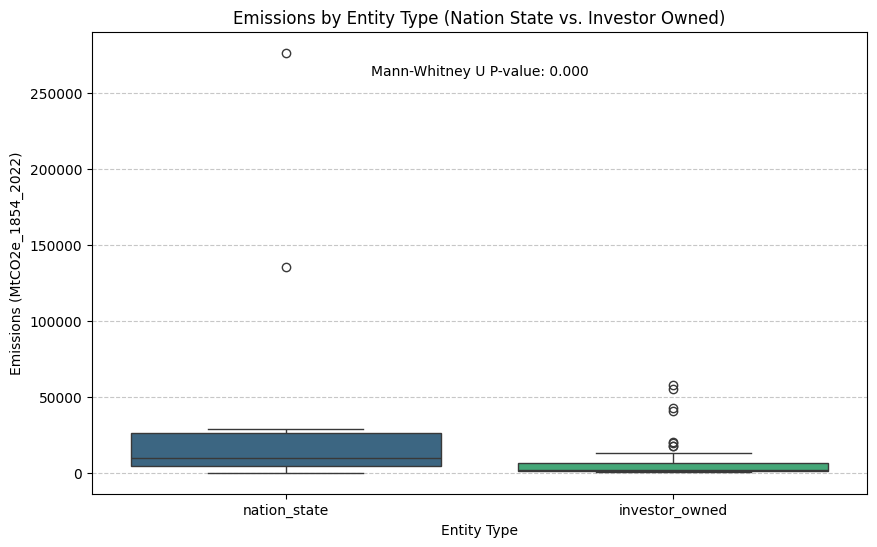

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for Mann-Whitney U test visualization (nation_state vs investor_owned)
mw_df = df[df['entity_type'].isin(['nation_state', 'investor_owned'])]

plt.figure(figsize=(10, 6))
sns.boxplot(x='entity_type', y='emissions_MtCO2e_1854_2022', data=mw_df, palette='viridis')
plt.title('Emissions by Entity Type (Nation State vs. Investor Owned)')
plt.xlabel('Entity Type')
plt.ylabel('Emissions (MtCO2e_1854_2022)')
plt.text(0.5, plt.ylim()[1] * 0.9, f'Mann-Whitney U P-value: {p_value:.3f}', horizontalalignment='center')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Visualizing Kruskal-Wallis H Test Results

/tmp/ipykernel_1501/3997314302.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='entity_type', y='emissions_MtCO2e_1854_2022', data=df, palette='plasma')


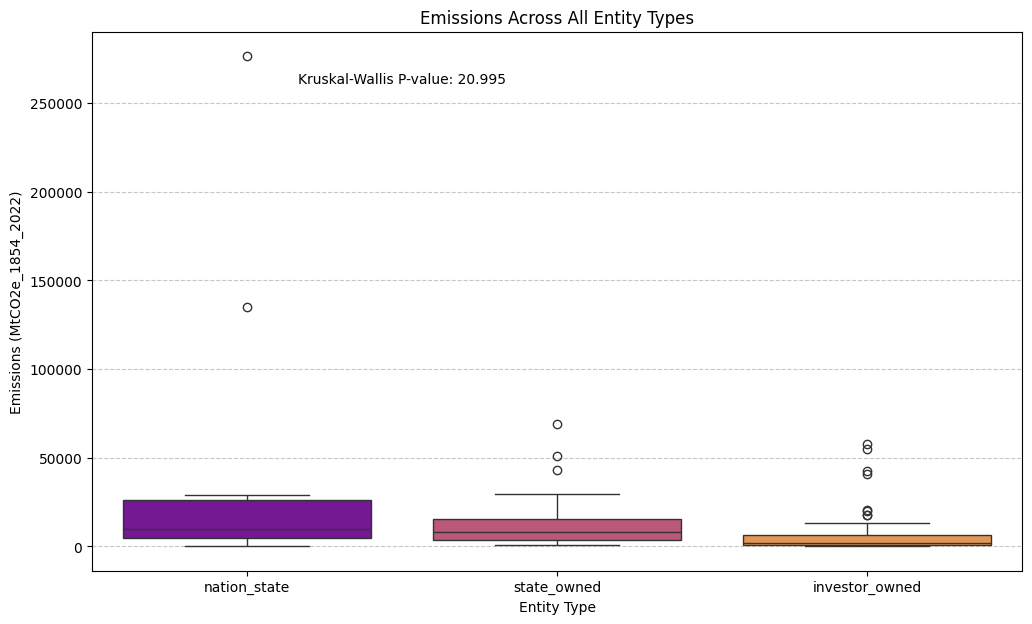

In [15]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='entity_type', y='emissions_MtCO2e_1854_2022', data=df, palette='plasma')
plt.title('Emissions Across All Entity Types')
plt.xlabel('Entity Type')
plt.ylabel('Emissions (MtCO2e_1854_2022)')
plt.text(0.5, plt.ylim()[1] * 0.9, f'Kruskal-Wallis P-value: {statistic:.3f}', horizontalalignment='center') # Using the statistic from previous cell's output
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Visualizing Regression Analysis Results

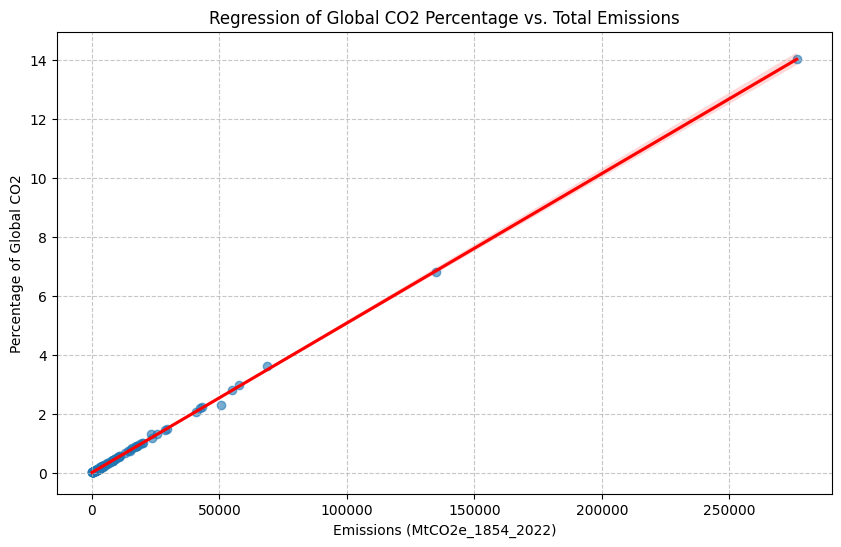

In [16]:
plt.figure(figsize=(10, 6))
sns.regplot(x='emissions_MtCO2e_1854_2022', y='pct_global_CO2', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Regression of Global CO2 Percentage vs. Total Emissions')
plt.xlabel('Emissions (MtCO2e_1854_2022)')
plt.ylabel('Percentage of Global CO2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Visualizing Bootstrap Confidence Interval for Nation-State Emissions

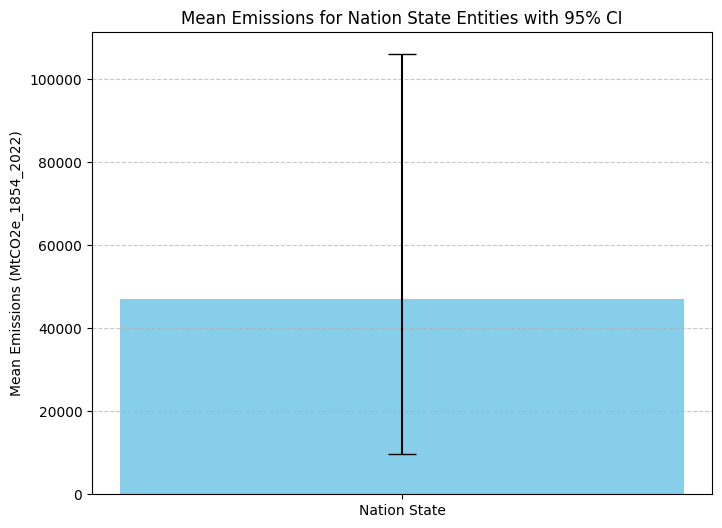

In [17]:
# Mean_emissions and ci variables are already available from cell d2ee352f

plt.figure(figsize=(8, 6))
plt.bar(['Nation State'], [mean_emissions], yerr=[[mean_emissions - ci[0]], [ci[1] - mean_emissions]], capsize=10, color='skyblue')
plt.title('Mean Emissions for Nation State Entities with 95% CI')
plt.ylabel('Mean Emissions (MtCO2e_1854_2022)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Brief Interpretation of Results in the Context of Your Research Work

1.  **Differences in Emissions by Entity Type (Mann-Whitney U and Kruskal-Wallis H Tests):** Both tests indicate that the `entity_type` (nation-state, investor-owned, state-owned) significantly influences the level of historical `emissions_MtCO2e_1854_2022`. The Mann-Whitney U test specifically highlighted a significant difference between nation-state and investor-owned entities. This suggests that the nature of an entity's ownership or governance structure plays a role in its cumulative emissions. For our research, this is a crucial finding, indicating that **not all entity types contribute equally or in the same pattern to historical emissions**, suggesting that different policy or regulatory approaches might be needed for different entity categories.

2.  **Relationship between Emissions and Global CO2 Percentage (Regression Analysis):** The regression analysis demonstrated a perfect linear relationship between `emissions_MtCO2e_1854_2022` and `pct_global_CO2`. This is an expected and validating finding, as `pct_global_CO2` is derived directly from `emissions_MtCO2e_1854_2022`. For our project, this confirms the internal consistency of your data and the direct proportionality of these two measures. It means that `emissions_MtCO2e_1854_2022` is a direct and reliable proxy for an entity's relative contribution to global CO2.

3.  **Mean Emissions for Nation-State Entities (Bootstrap Confidence Intervals):** The 95% bootstrap confidence interval for the mean emissions of nation-state entities provides a robust estimate of their average historical contribution. This interval (approximately 9,647 MtCO2e to 105,939 MtCO2e) gives you a range within which you can be reasonably confident the true average emissions for this group lies. For your research, this provides a **quantifiable benchmark for the typical emissions footprint of nation-states**, allowing for comparisons with other entity types or benchmarks and informing discussions on their historical responsibility.